# Federal minimum wage vs. the price of a Big Mac, 2000-2020

How fast did the U.S. federal minimum wage rise, and how fast did the price of a
McDonald's Big Mac rise over the same 21 years?

The two measures are in different units (dollars per hour vs. dollars per
sandwich), so comparing them means indexing both to 100 at their first
observation. That puts them on one shared axis, where the steeper line is
unambiguously the faster-growing series.

**Sources**
- `data/FEDMINNFRWG.csv` - FRED series [FEDMINNFRWG](https://fred.stlouisfed.org/series/FEDMINNFRWG), federal minimum hourly wage for nonfarm workers, monthly.
- `data/bigmac.csv` - the [Big Mac Index dataset](https://www.kaggle.com/datasets/mrmorj/big-mac-index-data) on Kaggle.

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# In a notebook the working directory is the notebook's own folder.
DATA_DIR = Path("data")
MINIMUM_WAGE_CSV = DATA_DIR / "FEDMINNFRWG.csv"
BIG_MAC_CSV = DATA_DIR / "bigmac.csv"

CHART_PATH = Path("minimum_wage_vs_big_mac.png")
TABLE_PATH = Path("minimum_wage_vs_big_mac.csv")

START_DATE = pd.Timestamp("2000-01-01")
END_DATE = pd.Timestamp("2020-12-31")

BASELINE_INDEX = 100.0  # both series are rebased to this at their first observation

# Colors are roles, not decoration: one hue per series, plus recessive chrome.
WAGE_COLOR = "#2a78d6"     # blue
BIG_MAC_COLOR = "#eb6834"  # orange
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"

## Loading the data

Each loader returns a single tidy `pd.Series` indexed by date, so the analysis
below never has to think about the shape of the source files.

In [2]:
def load_minimum_wage(csv_path: Path = MINIMUM_WAGE_CSV) -> pd.Series:
    """Return the monthly federal minimum wage in $/hour, indexed by date.

    Reads FRED's own CSV export for series FEDMINNFRWG. The export is two
    columns, ``observation_date`` and the series id, and it runs from 1938 to
    the present, so we slice out the window we care about.
    """
    frame = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    wage = frame.iloc[:, 0].astype(float)
    wage.name = "minimum_wage_usd_per_hour"
    return wage.loc[START_DATE:END_DATE].sort_index()


def load_big_mac_price(csv_path: Path = BIG_MAC_CSV) -> pd.Series:
    """Return the U.S. Big Mac price in $, indexed by survey date.

    The Big Mac Index table covers every surveyed country, so we keep the
    United States rows and read ``local_price``, which for the U.S. is already
    in dollars.
    """
    frame = pd.read_csv(csv_path, parse_dates=["date"])
    united_states = frame.loc[frame["iso_a3"] == "USA"]
    price = united_states.set_index("date")["local_price"].astype(float)
    price.name = "big_mac_price_usd"
    return price.loc[START_DATE:END_DATE].sort_index()


wage = load_minimum_wage()
price = load_big_mac_price()

print(f"minimum wage: {len(wage)} monthly observations, "
      f"{wage.index[0]:%Y-%m} to {wage.index[-1]:%Y-%m}")
print(f"big mac:      {len(price)} surveys, "
      f"{price.index[0]:%Y-%m} to {price.index[-1]:%Y-%m}")
price.head()

minimum wage: 252 monthly observations, 2000-01 to 2020-12
big mac:      33 surveys, 2000-04 to 2020-07


date
2000-04-01    2.24
2001-04-01    2.24
2002-04-01    2.35
2003-04-01    2.46
2004-05-01    2.47
Name: big_mac_price_usd, dtype: float64

## Measuring the rate of increase

`rebase_to_first_observation` is what makes the two series comparable. The growth
helpers give the headline numbers, and `big_macs_per_hour_worked` turns the gap
between the two into something concrete.

In [3]:
def rebase_to_first_observation(series: pd.Series) -> pd.Series:
    """Rescale a series so its first observation equals ``BASELINE_INDEX``."""
    return series / series.iloc[0] * BASELINE_INDEX


def total_growth_percent(series: pd.Series) -> float:
    """Percent increase from the first observation to the last."""
    return (series.iloc[-1] / series.iloc[0] - 1) * 100


def annualized_growth_percent(series: pd.Series) -> float:
    """Compound annual growth rate, in percent per year."""
    years = (series.index[-1] - series.index[0]).days / 365.25
    return ((series.iloc[-1] / series.iloc[0]) ** (1 / years) - 1) * 100


def big_macs_per_hour_worked(wage: pd.Series, price: pd.Series) -> pd.Series:
    """How many Big Macs one hour at the minimum wage buys, per survey date.

    The two sources are sampled on different calendars, so each Big Mac survey
    is matched to the minimum wage in effect on or before that date.
    """
    price_rows = price.rename_axis("date").reset_index()
    wage_rows = wage.rename_axis("date").reset_index()
    aligned = pd.merge_asof(
        price_rows, wage_rows, on="date", direction="backward"
    ).set_index("date")
    ratio = aligned["minimum_wage_usd_per_hour"] / aligned["big_mac_price_usd"]
    ratio.name = "big_macs_per_hour_worked"
    return ratio


print(f"Federal minimum wage: ${wage.iloc[0]:.2f} -> ${wage.iloc[-1]:.2f} "
      f"(+{total_growth_percent(wage):.1f}%, "
      f"{annualized_growth_percent(wage):.2f}%/yr)")
print(f"Big Mac price:        ${price.iloc[0]:.2f} -> ${price.iloc[-1]:.2f} "
      f"(+{total_growth_percent(price):.1f}%, "
      f"{annualized_growth_percent(price):.2f}%/yr)")

Federal minimum wage: $5.15 -> $7.25 (+40.8%, 1.65%/yr)
Big Mac price:        $2.24 -> $4.82 (+115.2%, 3.86%/yr)


## The chart

Two panels. The top one is the answer to the question: both series rebased to
100, so the slopes are directly comparable. The minimum wage is drawn as a step
function because it is one - it holds flat until Congress acts.

The bottom panel converts that gap into purchasing power: how many Big Macs an
hour of minimum-wage work actually buys.

In [4]:
def _style_axes(axes: plt.Axes) -> None:
    """Apply the shared, deliberately recessive chart chrome."""
    axes.set_facecolor(SURFACE)
    axes.grid(axis="y", color=GRID, linewidth=0.8)
    axes.set_axisbelow(True)
    for side in ("top", "right", "left"):
        axes.spines[side].set_visible(False)
    axes.spines["bottom"].set_color(GRID)
    axes.tick_params(colors=INK_MUTED, labelsize=9, length=0)


def _label_line_end(axes: plt.Axes, series: pd.Series, text: str, color: str) -> None:
    """Direct-label a series at its right-hand endpoint."""
    axes.annotate(
        text,
        xy=(series.index[-1], series.iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color=color,
        fontsize=10,
        fontweight="bold",
        va="center",
    )

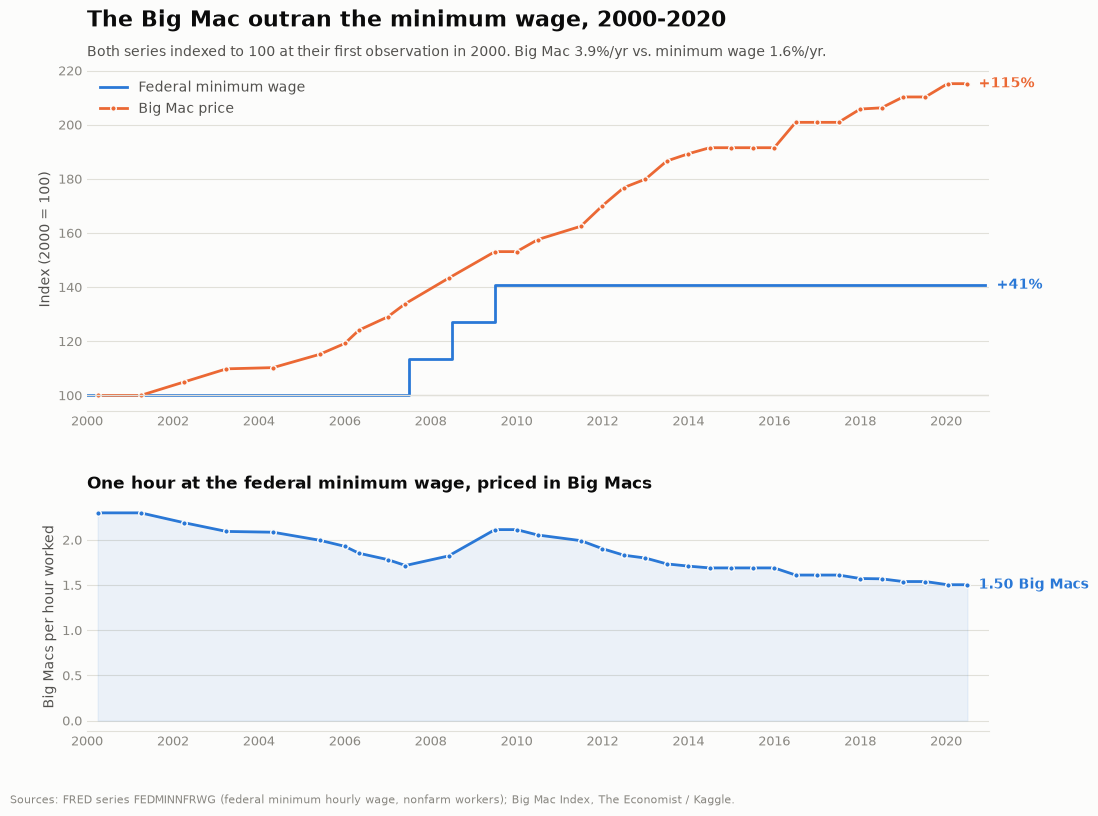

In [5]:
def plot_comparison(wage: pd.Series, price: pd.Series) -> plt.Figure:
    """Build the two-panel figure comparing the two rates of increase."""
    wage_index = rebase_to_first_observation(wage)
    price_index = rebase_to_first_observation(price)
    purchasing_power = big_macs_per_hour_worked(wage, price)

    figure, (ax_growth, ax_power) = plt.subplots(
        nrows=2,
        figsize=(11, 8.5),
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.32},
        facecolor=SURFACE,
    )

    # -- Panel 1: both series rebased to 100, so growth rates are comparable --
    ax_growth.plot(
        wage_index.index,
        wage_index.values,
        drawstyle="steps-post",
        color=WAGE_COLOR,
        linewidth=2,
        label="Federal minimum wage",
    )
    ax_growth.plot(
        price_index.index,
        price_index.values,
        color=BIG_MAC_COLOR,
        linewidth=2,
        marker="o",
        markersize=4,
        markerfacecolor=BIG_MAC_COLOR,
        markeredgecolor=SURFACE,
        markeredgewidth=1,
        label="Big Mac price",
    )
    ax_growth.axhline(BASELINE_INDEX, color=GRID, linewidth=1)

    _label_line_end(
        ax_growth, price_index, f"+{total_growth_percent(price):.0f}%", BIG_MAC_COLOR
    )
    _label_line_end(
        ax_growth, wage_index, f"+{total_growth_percent(wage):.0f}%", WAGE_COLOR
    )

    ax_growth.set_title(
        "The Big Mac outran the minimum wage, 2000-2020",
        fontsize=16,
        fontweight="bold",
        color=INK,
        loc="left",
        pad=30,
    )
    ax_growth.text(
        0.0,
        1.035,
        f"Both series indexed to 100 at their first observation in 2000. "
        f"Big Mac {annualized_growth_percent(price):.1f}%/yr vs. "
        f"minimum wage {annualized_growth_percent(wage):.1f}%/yr.",
        transform=ax_growth.transAxes,
        fontsize=10,
        color=INK_SECONDARY,
    )
    ax_growth.set_ylabel("Index (2000 = 100)", fontsize=10, color=INK_SECONDARY)
    ax_growth.legend(
        loc="upper left",
        frameon=False,
        fontsize=10,
        labelcolor=INK_SECONDARY,
    )

    # -- Panel 2: what that gap actually costs an hour of work --
    ax_power.plot(
        purchasing_power.index,
        purchasing_power.values,
        color=WAGE_COLOR,
        linewidth=2,
        marker="o",
        markersize=4,
        markerfacecolor=WAGE_COLOR,
        markeredgecolor=SURFACE,
        markeredgewidth=1,
    )
    ax_power.fill_between(
        purchasing_power.index, purchasing_power.values, color=WAGE_COLOR, alpha=0.08
    )
    _label_line_end(
        ax_power,
        purchasing_power,
        f"{purchasing_power.iloc[-1]:.2f} Big Macs",
        WAGE_COLOR,
    )
    ax_power.set_title(
        "One hour at the federal minimum wage, priced in Big Macs",
        fontsize=12,
        fontweight="bold",
        color=INK,
        loc="left",
        pad=10,
    )
    ax_power.set_ylabel("Big Macs per hour worked", fontsize=10, color=INK_SECONDARY)
    ax_power.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}"))

    for axes in (ax_growth, ax_power):
        _style_axes(axes)
        axes.set_xlim(START_DATE, END_DATE)

    figure.text(
        0.01,
        0.015,
        "Sources: FRED series FEDMINNFRWG (federal minimum hourly wage, nonfarm workers); "
        "Big Mac Index, The Economist / Kaggle.",
        fontsize=8,
        color=INK_MUTED,
    )
    figure.subplots_adjust(left=0.08, right=0.90, top=0.88, bottom=0.10)
    return figure


figure = plot_comparison(wage, price)
figure.savefig(CHART_PATH, dpi=200, facecolor=SURFACE)
plt.show()

## The numbers behind the chart

The table view of the same data, so every plotted value is readable without the
picture. This is also written to `minimum_wage_vs_big_mac.csv`.

In [6]:
def build_table(wage: pd.Series, price: pd.Series) -> pd.DataFrame:
    """The table-view twin of the chart: every plotted value, one row per survey."""
    table = pd.DataFrame({"big_mac_price_usd": price})
    table["minimum_wage_usd_per_hour"] = wage.reindex(
        price.index, method="ffill"
    ).values
    table["big_mac_index_2000_base"] = rebase_to_first_observation(price).round(1)
    table["minimum_wage_index_2000_base"] = (
        rebase_to_first_observation(table["minimum_wage_usd_per_hour"]).round(1)
    )
    table["big_macs_per_hour_worked"] = big_macs_per_hour_worked(wage, price).round(2)
    return table


table = build_table(wage, price)
table.to_csv(TABLE_PATH, float_format="%.2f")
table

,big_mac_price_usd,minimum_wage_usd_per_hour,big_mac_index_2000_base,minimum_wage_index_2000_base,big_macs_per_hour_worked
date,,,,,
2000-04-01,2.24,5.15,100.0,100.0,2.30
2001-04-01,2.24,5.15,100.0,100.0,2.30
2002-04-01,2.35,5.15,104.9,100.0,2.19
2003-04-01,2.46,5.15,109.8,100.0,2.09
2004-05-01,2.47,5.15,110.3,100.0,2.09
2005-06-01,2.58,5.15,115.2,100.0,2.00
2006-01-01,2.67,5.15,119.2,100.0,1.93
2006-05-01,2.78,5.15,124.1,100.0,1.85
2007-01-01,2.89,5.15,129.0,100.0,1.78


## Takeaway

Over 2000-2020 the Big Mac rose about **2.8x as fast** as the federal minimum
wage: +115% against +41%, or 3.9%/yr against 1.7%/yr. An hour of minimum-wage
work bought 2.30 Big Macs in 2000 and 1.50 in 2020.

Two caveats worth stating. Both series are nominal dollars, neither is
inflation-adjusted - that is the point of the comparison, since general
inflation is what sits between them. And this is the *federal* floor only; many
states set a higher one, so it understates what a lot of minimum-wage workers
actually earned.